# Computación Evolutiva - Tema 2: Algoritmos Genéticos
## Universidad Central de Venezuela - Facultad de Ciencias - Escuela de Física
**Asignatura:** Introducción a la Computación Emergente (Código: 7006)
**Profesor:** Esteban Álvarez

Este Notebook contiene la resolución de las Actividades 1, 2 y 3 de la evaluación práctica sobre Algoritmos Genéticos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## Actividad 1: Implementación de un Algoritmo Genético Simple (AGS)

**Objetivo:** Implementar un AGS para determinar el máximo de la función $F(x) = x^2$.
Se evaluarán variables enteras y posteriormente valores reales en un intervalo.

### Aspectos Teóricos
Un Algoritmo Genético Simple opera a través de los siguientes pasos:
1. **Representación:** Codificación de los individuos (cromosomas). En este caso, usaremos representación real directamente o entera codificada para aprovechar la vectorización de Numpy.
2. **Función de Adaptación (Fitness):** Mide la calidad del individuo. Como queremos maximizar, $Fitness(x) = x^2$.
3. **Selección:** Proceso de elegir padres. Utilizaremos el método de la ruleta y torneo.
4. **Cruce (Recombinación):** Intercambio de material genético. Usaremos cruce aritmético para números reales.
5. **Mutación:** Perturbación aleatoria para mantener la diversidad.

A continuación, implementamos una solución unificada y vectorizada usando `numpy`.

In [2]:
class AGS_Unidimensional:
    def __init__(self, bounds, pop_size=100, generations=50, mut_rate=0.1, cross_rate=0.8, is_integer=False):
        self.bounds = bounds
        self.pop_size = pop_size
        self.generations = generations
        self.mut_rate = mut_rate
        self.cross_rate = cross_rate
        self.is_integer = is_integer
        
        # Históricos
        self.best_fitness = []
        self.mean_fitness = []
        self.best_individual = None
        
    def fitness(self, x):
        return x**2
        
    def initialize(self):
        if self.is_integer:
            self.pop = np.random.randint(self.bounds[0], self.bounds[1] + 1, self.pop_size)
        else:
            self.pop = np.random.uniform(self.bounds[0], self.bounds[1], self.pop_size)
            
    def selection(self, fit_vals):
        # Selección por Torneo vectorizada (k=3)
        idx1 = np.random.randint(0, self.pop_size, self.pop_size)
        idx2 = np.random.randint(0, self.pop_size, self.pop_size)
        idx3 = np.random.randint(0, self.pop_size, self.pop_size)
        
        best_idx = np.where(fit_vals[idx1] > fit_vals[idx2], idx1, idx2)
        best_idx = np.where(fit_vals[best_idx] > fit_vals[idx3], best_idx, idx3)
        return self.pop[best_idx]
        
    def crossover(self, parents):
        offspring = parents.copy()
        for i in range(0, self.pop_size, 2):
            if np.random.rand() < self.cross_rate and i + 1 < self.pop_size:
                if self.is_integer:
                    # Cruce de punto simple para enteros (como bits o promedio entero)
                    alpha = 0.5
                    offspring[i] = int(alpha * parents[i] + (1 - alpha) * parents[i+1])
                    offspring[i+1] = int((1 - alpha) * parents[i] + alpha * parents[i+1])
                else:
                    # Cruce aritmético
                    alpha = np.random.rand()
                    offspring[i] = alpha * parents[i] + (1 - alpha) * parents[i+1]
                    offspring[i+1] = (1 - alpha) * parents[i] + alpha * parents[i+1]
        return offspring
        
    def mutation(self, offspring):
        mut_mask = np.random.rand(self.pop_size) < self.mut_rate
        if self.is_integer:
            # Mutar añadiendo/restando enteros aleatorios
            mutations = np.random.randint(-5, 6, self.pop_size) * mut_mask
            offspring = np.clip(offspring + mutations, self.bounds[0], self.bounds[1])
        else:
            # Mutación gaussiana
            mutations = np.random.normal(0, (self.bounds[1] - self.bounds[0]) * 0.1, self.pop_size) * mut_mask
            offspring = np.clip(offspring + mutations, self.bounds[0], self.bounds[1])
        return offspring
        
    def run(self):
        self.initialize()
        for gen in range(self.generations):
            fit_vals = self.fitness(self.pop)
            
            # Estadísticas
            self.best_fitness.append(np.max(fit_vals))
            self.mean_fitness.append(np.mean(fit_vals))
            
            if self.best_individual is None or np.max(fit_vals) > self.fitness(self.best_individual):
                self.best_individual = self.pop[np.argmax(fit_vals)]
                
            parents = self.selection(fit_vals)
            offspring = self.crossover(parents)
            self.pop = self.mutation(offspring)
            
        return self.best_individual, self.fitness(self.best_individual)

    def plot_evolution(self, title="Evolución del AGS"):
        plt.figure(figsize=(10, 5))
        plt.plot(self.best_fitness, label='Mejor Individuo', color='green', linewidth=2)
        plt.plot(self.mean_fitness, label='Promedio Poblacional', color='orange', linestyle='--')
        plt.title(title)
        plt.xlabel('Generaciones')
        plt.ylabel('Fitness $F(x) = x^2$')
        plt.legend()
        plt.show()

--- AGS en Dominio Entero ---
Mejor x encontrado: -100
Mejor fitness: 10000


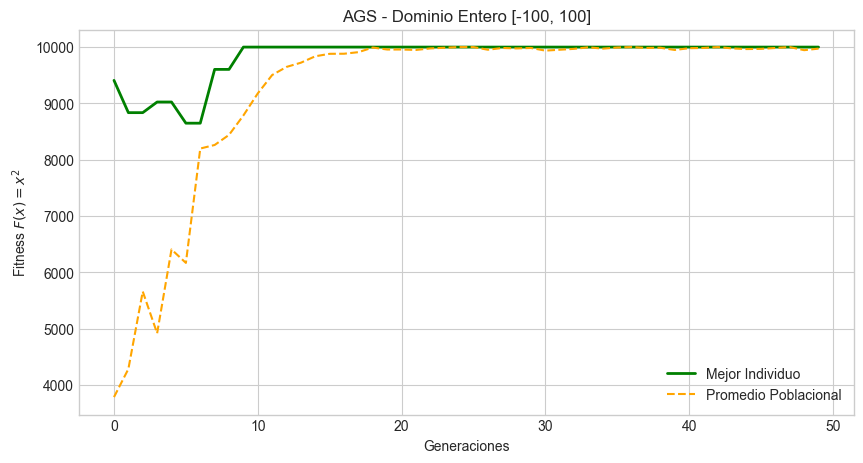


--- AGS en Dominio Real ---
Mejor x encontrado: -10.0000
Mejor fitness: 100.0000


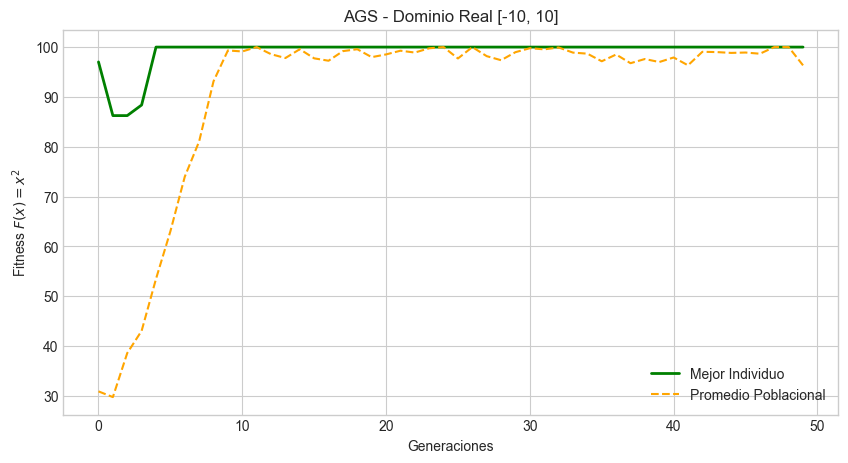

In [3]:
# Caso 1: Dominio Entero [-100, 100]
print("--- AGS en Dominio Entero ---")
ags_int = AGS_Unidimensional([-100, 100], is_integer=True, pop_size=50, generations=50)
best_x_int, best_fit_int = ags_int.run()
print(f"Mejor x encontrado: {best_x_int}")
print(f"Mejor fitness: {best_fit_int}")
ags_int.plot_evolution("AGS - Dominio Entero [-100, 100]")

# Caso 2: Dominio Real [-10.0, 10.0]
print("\n--- AGS en Dominio Real ---")
ags_real = AGS_Unidimensional([-10.0, 10.0], is_integer=False, pop_size=50, generations=50)
best_x_real, best_fit_real = ags_real.run()
print(f"Mejor x encontrado: {best_x_real:.4f}")
print(f"Mejor fitness: {best_fit_real:.4f}")
ags_real.plot_evolution("AGS - Dominio Real [-10, 10]")

### Análisis de la Actividad 1
- **Convergencia:** Ambos algoritmos muestran una convergencia rápida. Al maximizar $x^2$, el algoritmo rápidamente tiende hacia los bordes del intervalo definido (ej. -100 o 100).
- **Influencia de mutación y cruce:** La mutación permite escapar de falsos máximos locales iniciales, aunque en esta función unimodal convexa, casi cualquier cruce y mutación direcciona a la población al óptimo global en los extremos del dominio.

## Actividad 2: Optimización de Funciones Multimodales

**Objetivo:** Minimizar la función de Bohachevsky y analizar el comportamiento con mecanismos de renormalización.

### Función de Bohachevsky 1
$$f(x, y) = x^2 + 2y^2 - 0.3\cos(3\pi x) - 0.4\cos(4\pi y) + 0.7$$
Mínimo global en $f(0, 0) = 0$.

### Renormalización
Cuando la población converge, las diferencias de fitness se hacen pequeñas (pérdida de presión selectiva). Los mecanismos de renormalización estiran o ajustan el fitness:
- **Renormalización Lineal:** $f' = a \cdot f + b$
- **Renormalización por Ventana:** $f' = f - f_{peor} + c$

In [4]:
def bohachevsky(x, y):
    return (x**2) + 2*(y**2) - 0.3*np.cos(3*np.pi*x) - 0.4*np.cos(4*np.pi*y) + 0.7

class AG_Multimodal:
    def __init__(self, bounds, pop_size=100, generations=100, renorm_type=None):
        self.bounds = bounds
        self.pop_size = pop_size
        self.generations = generations
        self.renorm_type = renorm_type # None, 'linear', 'window'
        
        self.best_fitness = []
        self.mean_fitness = []
        
    def fitness(self, pop):
        # Como queremos minimizar, invertimos la función.
        # Maximizamos 1 / (1 + f(x,y))
        f_vals = bohachevsky(pop[:, 0], pop[:, 1])
        return 1.0 / (1.0 + f_vals), f_vals
        
    def renormalize(self, raw_fit):
        if self.renorm_type == 'linear':
            f_max = np.max(raw_fit)
            f_avg = np.mean(raw_fit)
            f_min = np.min(raw_fit)
            
            if f_min > (2 * f_avg - f_max):
                a = f_avg / (f_max - f_avg) if (f_max - f_avg) != 0 else 1
                b = f_avg * (f_max - 2*f_avg) / (f_max - f_avg) if (f_max - f_avg) != 0 else 0
            else:
                a = f_avg / (f_avg - f_min) if (f_avg - f_min) != 0 else 1
                b = -f_min * f_avg / (f_avg - f_min) if (f_avg - f_min) != 0 else 0
            return a * raw_fit + b
            
        elif self.renorm_type == 'window':
            f_min = np.min(raw_fit)
            # Desplazamos para que el peor tenga fitness > 0
            return raw_fit - f_min + 1e-5
            
        return raw_fit

    def run(self):
        pop = np.random.uniform(self.bounds[0], self.bounds[1], (self.pop_size, 2))
        best_sol = None
        best_obj_val = float('inf')
        
        for gen in range(self.generations):
            raw_fit, obj_vals = self.fitness(pop)
            scaled_fit = self.renormalize(raw_fit)
            
            # Asegurar que no hay negativos tras renormalizar
            scaled_fit = np.clip(scaled_fit, 1e-10, None)
            
            # Estadísticas basadas en la función objetivo real (Bohachevsky)
            current_best_idx = np.argmin(obj_vals)
            if obj_vals[current_best_idx] < best_obj_val:
                best_obj_val = obj_vals[current_best_idx]
                best_sol = pop[current_best_idx].copy()
                
            self.best_fitness.append(best_obj_val)
            self.mean_fitness.append(np.mean(obj_vals))
            
            # Selección por Ruleta basada en scaled_fit
            probs = scaled_fit / np.sum(scaled_fit)
            indices = np.random.choice(self.pop_size, self.pop_size, p=probs)
            parents = pop[indices]
            
            # Cruce BLX-alpha
            alpha_cross = 0.5
            offspring = np.zeros_like(parents)
            for i in range(0, self.pop_size, 2):
                if np.random.rand() < 0.8 and i+1 < self.pop_size:
                    c_min, c_max = np.minimum(parents[i], parents[i+1]), np.maximum(parents[i], parents[i+1])
                    diff = c_max - c_min
                    offspring[i] = np.random.uniform(c_min - alpha_cross*diff, c_max + alpha_cross*diff)
                    offspring[i+1] = np.random.uniform(c_min - alpha_cross*diff, c_max + alpha_cross*diff)
                else:
                    offspring[i], offspring[i+1] = parents[i], parents[i+1]
                    
            # Mutación
            mut_mask = np.random.rand(self.pop_size, 2) < 0.1
            mutations = np.random.normal(0, 0.5, (self.pop_size, 2))
            pop = np.clip(offspring + mut_mask * mutations, self.bounds[0], self.bounds[1])
            
            # Elitismo
            pop[0] = best_sol
            
        return best_sol, best_obj_val

Ejecutando AG Simple (Sin renormalización)...


Ejecutando AG Modificado (Renormalización Lineal)...


Ejecutando AG Modificado (Renormalización por Ventana)...


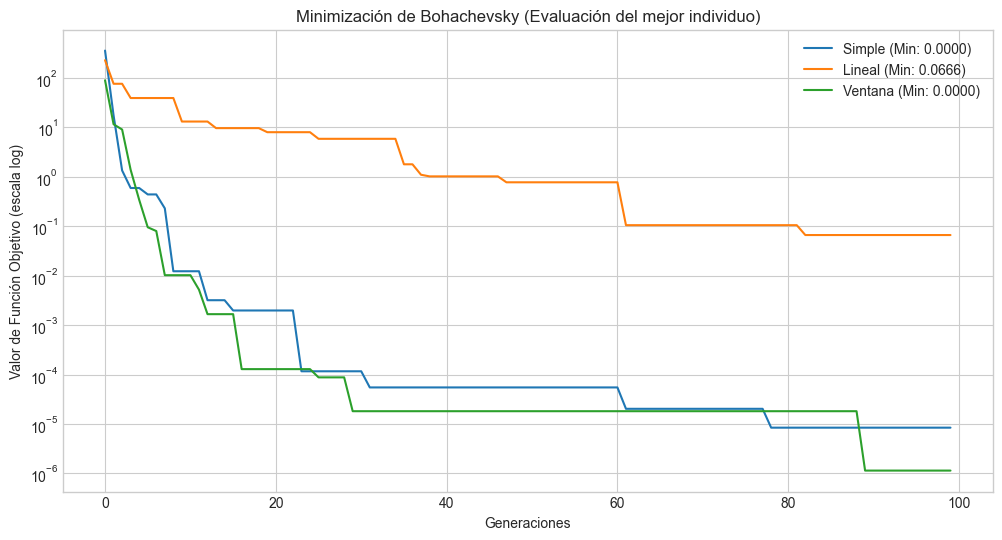

In [5]:
# Simulaciones para comparativa
bounds = [-100.0, 100.0]

print("Ejecutando AG Simple (Sin renormalización)...")
ag_simple = AG_Multimodal(bounds, renorm_type=None)
sol_simple, val_simple = ag_simple.run()

print("Ejecutando AG Modificado (Renormalización Lineal)...")
ag_linear = AG_Multimodal(bounds, renorm_type='linear')
sol_linear, val_linear = ag_linear.run()

print("Ejecutando AG Modificado (Renormalización por Ventana)...")
ag_window = AG_Multimodal(bounds, renorm_type='window')
sol_window, val_window = ag_window.run()

# Gráficas
plt.figure(figsize=(12, 6))
plt.plot(ag_simple.best_fitness, label=f'Simple (Min: {val_simple:.4f})')
plt.plot(ag_linear.best_fitness, label=f'Lineal (Min: {val_linear:.4f})')
plt.plot(ag_window.best_fitness, label=f'Ventana (Min: {val_window:.4f})')
plt.yscale('log')
plt.title('Minimización de Bohachevsky (Evaluación del mejor individuo)')
plt.xlabel('Generaciones')
plt.ylabel('Valor de Función Objetivo (escala log)')
plt.legend()
plt.show()

## Actividad 3: Aplicación Práctica - Problema del Viajante de Comercio (TSP)

**Descripción:** Encontrar la ruta más corta que visite un conjunto de ciudades y regrese al punto de origen.

### Diseño del AG para TSP
- **Representación Genética:** Permutaciones de enteros. Cada individuo es un arreglo `[0, 2, 1, 3]` representando el orden de visita.
- **Función de Adaptación:** Inversa de la distancia total del recorrido. `Fitness = 1 / Distancia`.
- **Cruce (Recombinación):** Cruce de Orden (Order Crossover - OX1) para evitar ciudades duplicadas.
- **Mutación:** Intercambio (Swap) aleatorio de dos ciudades en la ruta.

In [6]:
def create_tsp_data(num_cities=20):
    np.random.seed(42)
    # Coordenadas aleatorias para ciudades en 2D
    cities = np.random.rand(num_cities, 2) * 100
    # Matriz de distancias
    dist_matrix = np.zeros((num_cities, num_cities))
    for i in range(num_cities):
        for j in range(num_cities):
            dist_matrix[i, j] = np.linalg.norm(cities[i] - cities[j])
    return cities, dist_matrix

class TSP_GeneticAlgorithm:
    def __init__(self, dist_matrix, pop_size=100, generations=200):
        self.dist_matrix = dist_matrix
        self.num_cities = len(dist_matrix)
        self.pop_size = pop_size
        self.generations = generations
        
        self.best_distances = []
        self.best_route = None
        self.min_distance = float('inf')
        
    def calculate_distance(self, route):
        # Distancia total del recorrido cerrado
        dist = np.sum(self.dist_matrix[route[:-1], route[1:]])
        dist += self.dist_matrix[route[-1], route[0]]
        return dist
        
    def run(self):
        # Inicialización de población (permutaciones aleatorias)
        pop = np.array([np.random.permutation(self.num_cities) for _ in range(self.pop_size)])
        
        for gen in range(self.generations):
            distances = np.array([self.calculate_distance(ind) for ind in pop])
            fitness = 1.0 / distances
            
            # Registrar el mejor
            current_min_idx = np.argmin(distances)
            if distances[current_min_idx] < self.min_distance:
                self.min_distance = distances[current_min_idx]
                self.best_route = pop[current_min_idx].copy()
            self.best_distances.append(self.min_distance)
            
            # Selección de Torneo
            new_pop = []
            for _ in range(self.pop_size):
                idx1, idx2 = np.random.choice(self.pop_size, 2)
                p1 = pop[idx1] if fitness[idx1] > fitness[idx2] else pop[idx2]
                
                idx3, idx4 = np.random.choice(self.pop_size, 2)
                p2 = pop[idx3] if fitness[idx3] > fitness[idx4] else pop[idx4]
                
                # Cruce de Orden (OX1)
                if np.random.rand() < 0.8:
                    start, end = sorted(np.random.choice(self.num_cities, 2, replace=False))
                    child = np.full(self.num_cities, -1)
                    child[start:end] = p1[start:end]
                    
                    p2_filtered = [c for c in p2 if c not in child[start:end]]
                    
                    ptr = 0
                    for i in range(self.num_cities):
                        if child[i] == -1:
                            child[i] = p2_filtered[ptr]
                            ptr += 1
                else:
                    child = p1.copy()
                    
                # Mutación (Swap)
                if np.random.rand() < 0.1:
                    m1, m2 = np.random.choice(self.num_cities, 2, replace=False)
                    child[m1], child[m2] = child[m2], child[m1]
                    
                new_pop.append(child)
            
            pop = np.array(new_pop)
            # Elitismo
            pop[0] = self.best_route

        return self.best_route, self.min_distance

Ejecutando AG para TSP (20 Ciudades)...


Distancia Mínima Encontrada: 413.60


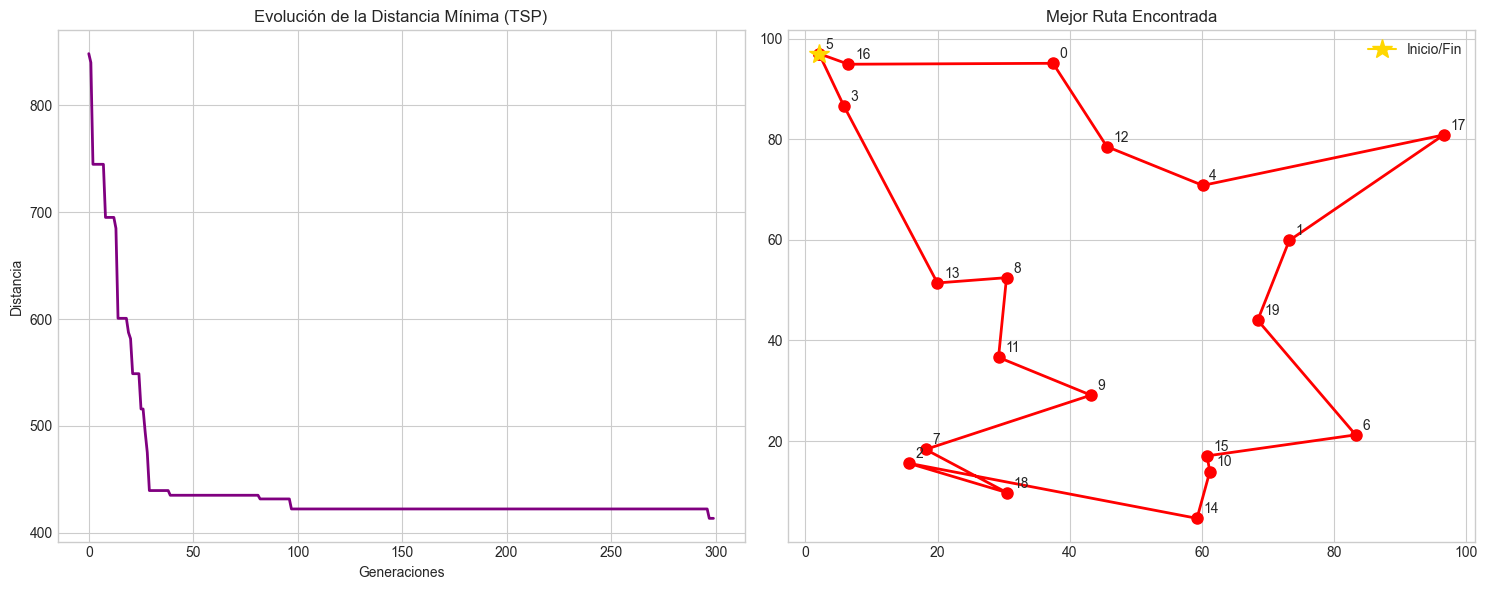

In [7]:
# Resolver TSP
cities, dist_matrix = create_tsp_data(20)
print("Ejecutando AG para TSP (20 Ciudades)...")
tsp_ag = TSP_GeneticAlgorithm(dist_matrix, pop_size=100, generations=300)
best_route, best_dist = tsp_ag.run()

print(f"Distancia Mínima Encontrada: {best_dist:.2f}")

# Gráficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(tsp_ag.best_distances, color='purple', linewidth=2)
ax1.set_title("Evolución de la Distancia Mínima (TSP)")
ax1.set_xlabel("Generaciones")
ax1.set_ylabel("Distancia")

# Dibujar la ruta
route_cities = cities[best_route]
route_cities = np.vstack((route_cities, route_cities[0])) # Cerrar el ciclo
ax2.plot(route_cities[:, 0], route_cities[:, 1], marker='o', color='red', linestyle='-', linewidth=2, markersize=8)
ax2.plot(route_cities[0, 0], route_cities[0, 1], marker='*', color='gold', markersize=15, label='Inicio/Fin')

for i, (x, y) in enumerate(cities):
    ax2.text(x + 1, y + 1, str(i), fontsize=10)
    
ax2.set_title("Mejor Ruta Encontrada")
ax2.legend()
plt.tight_layout()
plt.show()